# Progetto di Cavallari Anna matr. 1099291 e Gobbo Chiara matr.1096072

## ANALISI SU DATASET AI JOB RECOMMENDATION
- Preprocessing
- Distribuzione delle variabili
- Clustering (K-Means e DBSCAN)
- Modelli di Machine Learning (Logistic Regression, Random Forest)

___
## 1. Importazione librerie

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.cluster import KMeans, DBSCAN
from scipy.stats import chi2_contingency

print('Librerie caricate') 

Librerie caricate


___
## 2. Caricamento del dataset

In [77]:
file_path = "ds/job_recommendation_structured.csv"
df = pd.read_csv(file_path)
print(f"Dataset caricato: {df.shape[0]:,} righe × {df.shape[1]} colonne")

Dataset caricato: 50,000 righe × 7 colonne


___
## 3. Ispezione iniziale del dataset

Prime 5 righe e informazioni generali sulle colonne (tipo, valori non nulli)

In [78]:
print("Prime righe del dataset")
print(df.head())

print("\nInfo")
print(df.info())

Prime righe del dataset
                         Job Title                      Company  \
0              Early years teacher               Richardson Ltd   
1         Counselling psychologist  Ramos, Santiago and Stewart   
2        Radio broadcast assistant                 Franco Group   
3     Designer, exhibition/display                  Collins Inc   
4  Psychotherapist, dance movement                 Barker Group   

        Location Experience Level    Salary     Industry  \
0         Sydney     Senior Level   81800.0       EdTech   
1  San Francisco        Mid Level  105800.0  IT Services   
2       New York        Mid Level   56300.0       EdTech   
3         Berlin     Senior Level  135700.0   Healthcare   
4         Sydney      Entry Level   76900.0     Software   

                               Required Skills  
0      Pedagogy, Curriculum Design, E-learning  
1                              AWS, React, SQL  
2                E-learning, Curriculum Design  
3  Patient Care,

___
## 4. Controllo valori manccanti

Verifichiamo la presenza di missing values nel dataset

In [79]:
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean() * 100
}).query('count > 0').sort_values('percent', ascending=False)


if missing.empty:
    print('Nessun valore mancante')
else:
    print(f'{len(missing)} colonne con valori mancanti:')
    display(missing.style.bar(subset=['percent'], color='#d65f5f'))

df.isnull().sum()


Nessun valore mancante


Job Title           0
Company             0
Location            0
Experience Level    0
Salary              0
Industry            0
Required Skills     0
dtype: int64

___
## 5. Controllo righe duplicate

In [80]:
n_dup = df.duplicated().sum()
print(f'Righe duplicate: {n_dup} ({n_dup / len(df) * 100:.2f}%)')

Righe duplicate: 0 (0.00%)


___
## 6. Analisi delle variabili categoriali

Identifichiamo le colonne testuali e categoriali per valutare la cardinalità, cioè il numero di valori univoci

In [81]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f'Colonne categoriche ({len(cat_cols)}): {cat_cols}')

Colonne categoriche (6): ['Job Title', 'Company', 'Location', 'Experience Level', 'Industry', 'Required Skills']


In [82]:
df.columns

Index(['Job Title', 'Company', 'Location', 'Experience Level', 'Salary',
       'Industry', 'Required Skills'],
      dtype='str')

### Cardinalità

In [83]:
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
print('Cardinalità colonne categoriche:')
display(cardinality.to_frame('n_unique'))

Cardinalità colonne categoriche:


,n_unique
Company,37022
Job Title,639
Required Skills,250
Industry,8
Location,7
Experience Level,3


Geestione esclusione ddelle colonne con tanti valori univoci e difficili da gestire

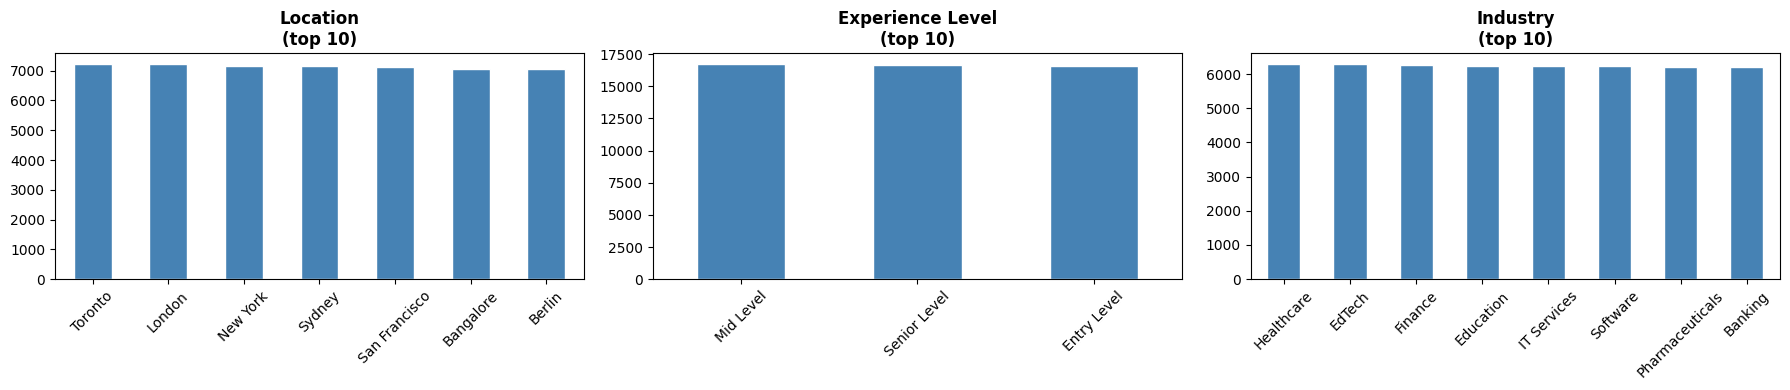

In [84]:
low_card = [c for c in cat_cols if df[c].nunique() <= 50]

if low_card:
    n = len(low_card)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    
    for ax, col in zip(axes, low_card):
        counts = df[col].value_counts().head(10)
        counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(f'{col}\n(top 10)', fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print('Tutte le colonne categoriche hanno alta cardinalità (> 50 valori).')

___
## 7. Analisi delle variabili numeriche

Il dataset contiene una sola variabile numerica continua: `Salary`.
Ne osserviamo la distribuzione tramite istogramma:

Colonne numeriche: ['Salary']


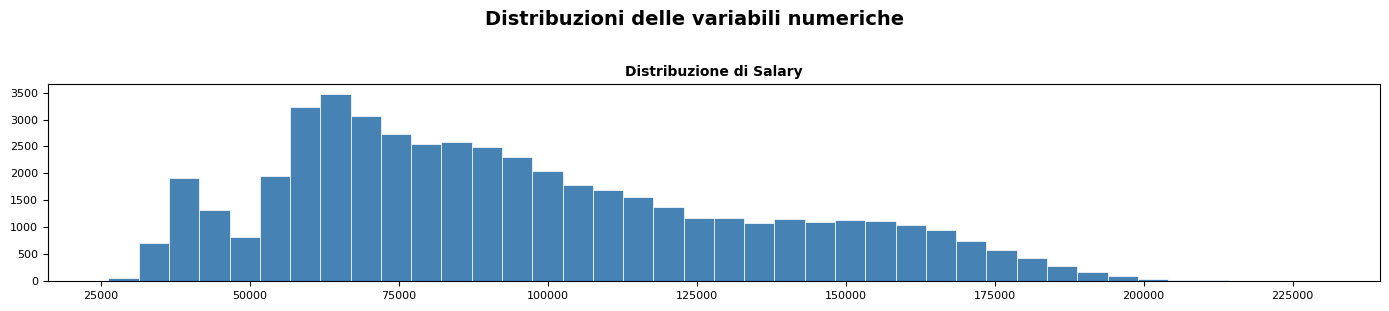

In [85]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print("Colonne numeriche:", num_cols)

# Numero di feature numeriche
n = len(num_cols)

fig, axes = plt.subplots(n, 1, figsize=(14, n * 3))
axes = np.array(axes).reshape(-1).flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'Distribuzione di {col}', fontsize=10, fontweight='bold')
    axes[i].tick_params(labelsize=8)

# Nasconde eventuali assi vuoti
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuzioni delle variabili numeriche', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

___
## 8. Box plot

Analisi della distribuzione del salario e di come varia questo in base alle altre variabili categoriali

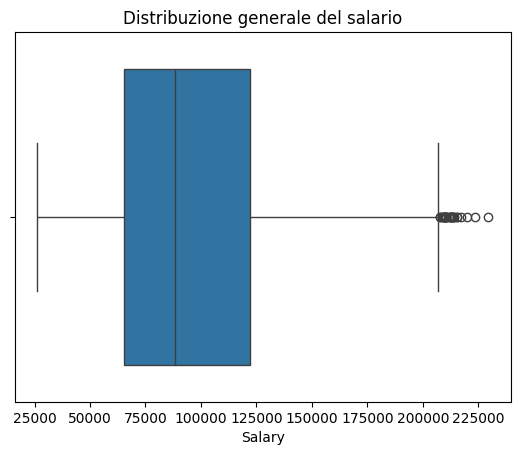

In [86]:
sns.boxplot(x=df['Salary'])
plt.title("Distribuzione generale del salario")
plt.show()

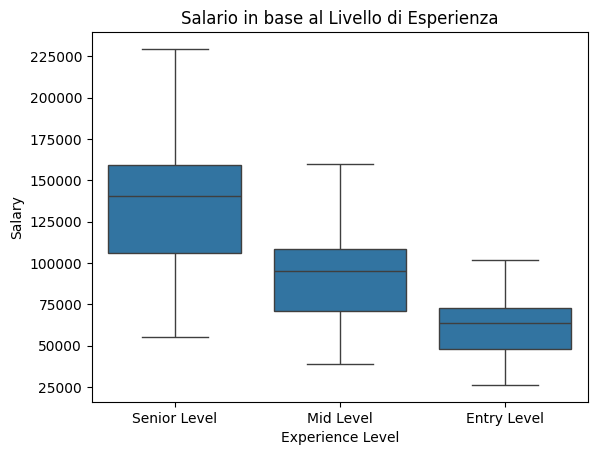

In [87]:
sns.boxplot(x='Experience Level', y='Salary', data=df)
plt.title("Salario in base al Livello di Esperienza")
plt.show()

Si osserva che il salario varia tra i diversi livelli di esperienza, ciò significa nel dataset esiste una relazione tra esperienza e salario

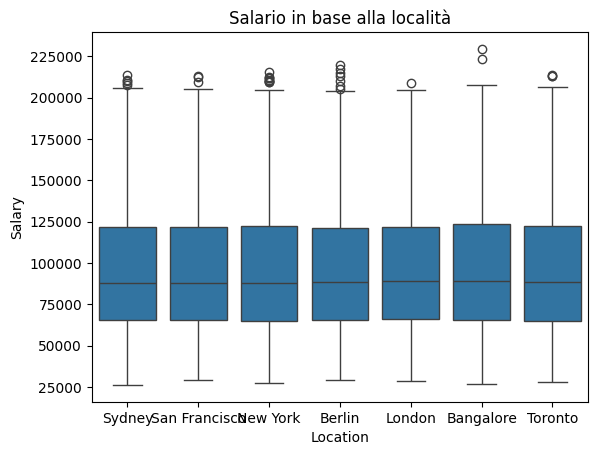

In [88]:
sns.boxplot(x='Location', y='Salary', data=df)
plt.title("Salario in base alla località")
plt.show()

In questo caso non ci son delle differenze rilevanti ma minime, ad esempio a New York il terzo quartile tocca un livello di salario più basso rispetto alle altre città, mentre London ha suo primo quartile che parte da un livello di salario base più alto. La mediana più alta si trova in Bangalore

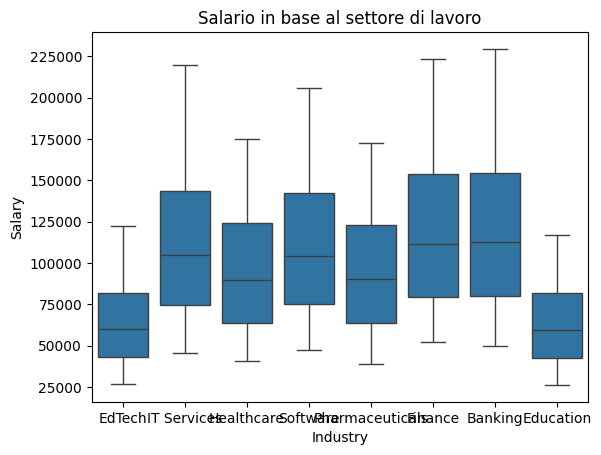

In [89]:
sns.boxplot(x='Industry', y='Salary', data=df)
plt.title("Salario in base al settore di lavoro")
plt.show()

aggiungere commento boxplot

___
## 9. Analisi delle Correlazioni

### 9.1 Chi-Quadro delle variabili categoriali

Verificihiamo con il Chi-Quadro se esiste una relazione statistica significativa tra `Industry` e `Experience Level`

Risultati tra 'Industry' e 'Experience Level':
P-value: 0.2488 Chi2: 17.1408 Gradi di libertà: 14
Non c'è una relazione statistica significativa


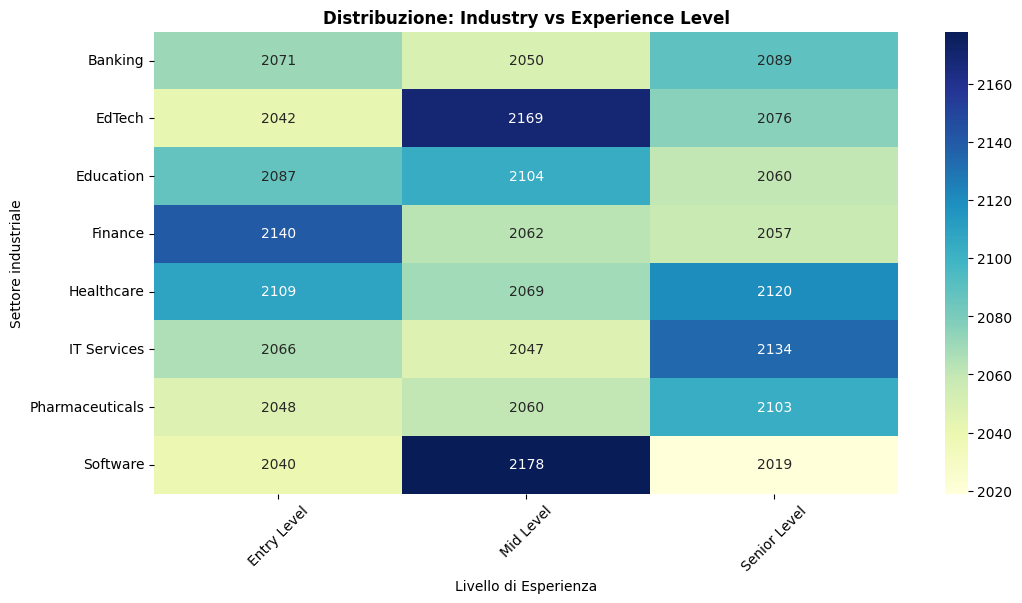

In [90]:
cat_cols_corr = ['Industry', 'Experience Level'] 

# quante osservazioni cadono per ogni combinazone
contingency_table = pd.crosstab(df[cat_cols_corr[0]], df[cat_cols_corr[1]])

# Chi-Quadrato
chi2, p, dof, ex = chi2_contingency(contingency_table)

print(f"Risultati tra '{cat_cols_corr[0]}' e '{cat_cols_corr[1]}':")
print(f"P-value: {p:.4f} Chi2: {chi2:.4f} Gradi di libertà: {dof}")

if p < 0.05:
    print("Esiste una relazione significativa tra ruolo e livello di esperienza")
else:
    print("Non c'è una relazione statistica significativa")

plt.figure(figsize=(12, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Distribuzione: {cat_cols_corr[0]} vs {cat_cols_corr[1]}', fontweight='bold')
plt.xlabel('Livello di Esperienza')
plt.ylabel('Settore industriale')
plt.xticks(rotation=45)
plt.show()

Inserire commento

### 9.2 Distribuzione del salario per livello di esperienza

<Axes: xlabel='Salary', ylabel='Count'>

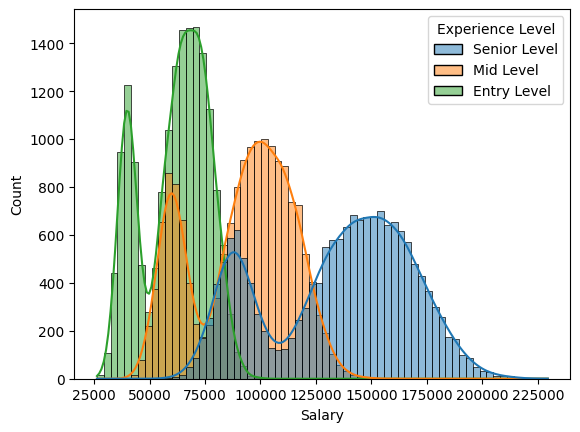

In [91]:
sns.histplot(df, x='Salary', hue='Experience Level', kde=True)

Inserire commento

___
## 10. Analisi delle skills più richieste

La colonna `Required Skills` contiene più skill separate da virgola, bisogn normalizzare qquesta cella

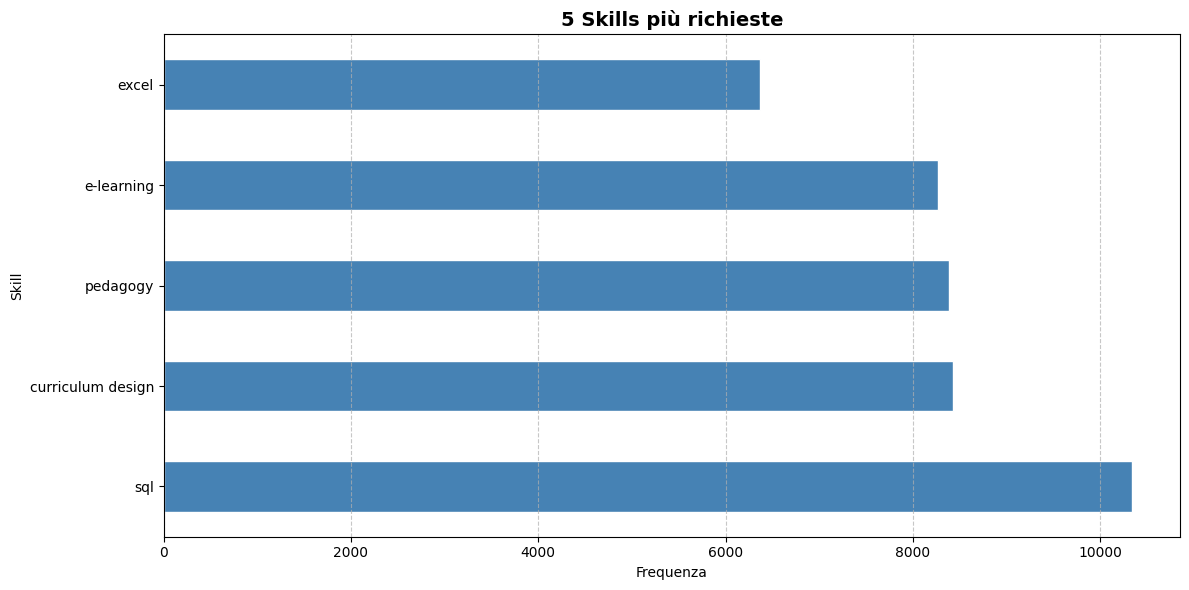

In [92]:


# Dividiamo le stringhe dove c'è la virgola
skills_split = df['Required Skills'].str.split(',', expand=True) # expand=True crea un DataFrame con una colonna per ogni skill

# Trasformiamo tutto il DataFrame in una singola colonna (Series)
# stack() "impila" tutte le colonne una sotto l'altra
all_skills = skills_split.stack()

# Togliamo spazi bianchi e mettiamo tutto in minuscolo
all_skills = all_skills.str.strip().str.lower()

# Contiamo le occorrenze e prendiamo le prime 5
top_5_skills = all_skills.value_counts().head(5)

plt.figure(figsize=(12, 6))
top_5_skills.plot(kind='barh', color='steelblue', edgecolor='white')

plt.title('5 Skills più richieste', fontsize=14, fontweight='bold')
plt.xlabel('Frequenza')
plt.ylabel('Skill')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


le competenze più richieste nel datasetsono SQL e curriculum design come le skill più frequenti, seguite da pedagogia, e-learning e excel

___
## 11. Media del salario per livello di eesperienza

In [93]:
mean_salary = df.groupby('Experience Level')['Salary'].mean().sort_values(ascending=False)
print("Media salario per livello di esperienza")
print(mean_salary.to_frame('Salary medio').round(2))

Media salario per livello di esperienza
                  Salary medio
Experience Level              
Senior Level         134709.19
Mid Level             91536.24
Entry Level           61304.07


# QUI NON SO CHE FARE 

In [94]:
#le_exp = LabelEncoder()
#le_ind = LabelEncoder()
#le_loc = LabelEncoder()

#df['Experience Level'] = le_exp.fit_transform(df['Experience Level'])
#df['Industry'] = le_ind.fit_transform(df['Industry'])
#df['Location'] = le_loc.fit_transform(df['Location'])
#print(le_exp.classes_)

In [95]:
# Target e feature
#X = df[['Salary', 'Industry', 'Location']]
#y = df['Experience Level']

In [96]:
#cat_cols = ['Industry', 'Location']
#num_cols = ['Salary']



############### No Anna aspetta non ho capito che cosa vuoi fare, ho commentato tutto perchè
############### altrimenti ho errori strani, in caso continua tu o facciamo chiamata


___
## 12. Preprocessing per il Clustering

Per poter applicare algoritmi di clustering (LAVORANO CON DATI NUMERICI) dobbiamo:
1. Rendere le variabili categoriche numeriche
2. Standardizzare TUTTE le feature con StandardScaler (media 0, deviazione standard 1)

Usiamo le variabili `Location`, `Experience Level`, `Industry` e `Salary`.

In [97]:
cols_to_encode = ['Location', 'Experience Level', 'Industry']

df_numeric = pd.get_dummies(
    df[['Location', 'Experience Level', 'Industry', 'Salary']],
    columns=cols_to_encode
).astype(float)

print(f"Feature dopo One-Hot Encoding: {df_numeric.shape[1]} colonne")
print(df_numeric.columns.tolist())

Feature dopo One-Hot Encoding: 19 colonne
['Salary', 'Location_Bangalore', 'Location_Berlin', 'Location_London', 'Location_New York', 'Location_San Francisco', 'Location_Sydney', 'Location_Toronto', 'Experience Level_Entry Level', 'Experience Level_Mid Level', 'Experience Level_Senior Level', 'Industry_Banking', 'Industry_EdTech', 'Industry_Education', 'Industry_Finance', 'Industry_Healthcare', 'Industry_IT Services', 'Industry_Pharmaceuticals', 'Industry_Software']


Mettiamo lo scaler perchè la variabile Salary ha una scalatura diversa da quella delle variabili dummy create sopra e i modelli ci danno più importanza

In [98]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

print(f"{X_scaled.shape}")

(50000, 19)


___
## 13. Clustering

### 13.1 Metodo del gomito
Prima di applicare K-Means, usiamo il metodo del gomito per determinare il numero ottimale di cluster `k`.
L'inerzia è la somma delle distanze al quadrato di ogni punto dal suo centroide: al crescere di `k` l'inerzia decresce, ma oltre un certo punto il guadagno diventa trascurabile

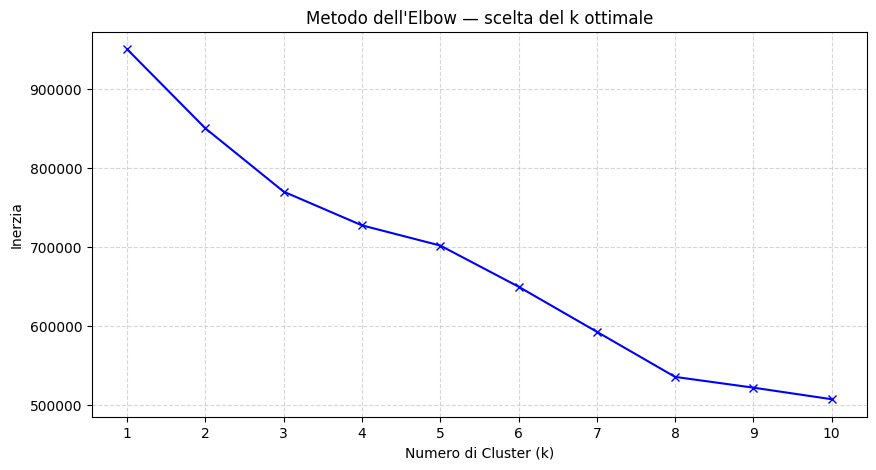

In [100]:
inertia = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Numero di Cluster (k)')
plt.ylabel('Inerzia')
plt.title("Metodo dell'Elbow — scelta del k ottimale")
plt.xticks(K)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 13.2 K-Means

In [110]:
# Creiamo la colonna 'Cluster' per K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Distribuzione dei campioni nei cluster:")
print(df['Cluster'].value_counts().sort_index())

Distribuzione dei campioni nei cluster:
Cluster
0    16658
1    16739
2    16603
Name: count, dtype: int64


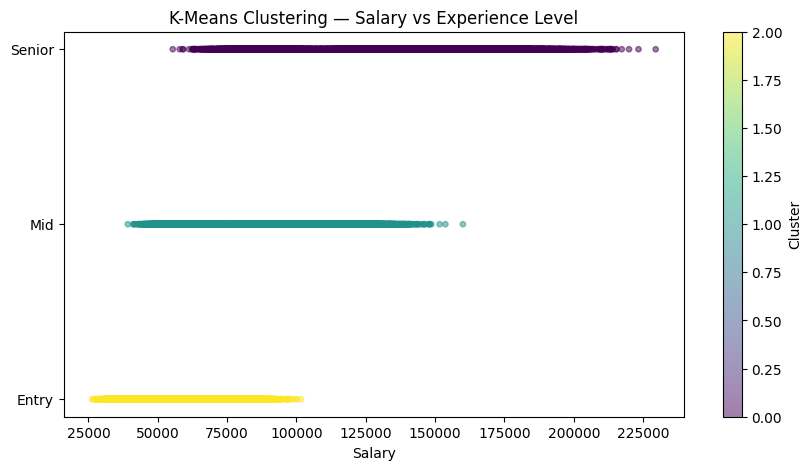

In [109]:
exp_map = {'Entry Level': 0, 'Mid Level': 1, 'Senior Level': 2}
df['exp_num'] = df['Experience Level'].map(exp_map)

plt.figure(figsize=(10, 5))
plt.scatter(df['Salary'], df['exp_num'], c=df['Cluster'], cmap='viridis', s=15, alpha=0.5)
plt.yticks([0, 1, 2], ['Entry', 'Mid', 'Senior'])
plt.xlabel('Salary')
plt.title('K-Means Clustering — Salary vs Experience Level')
plt.colorbar(label='Cluster')
plt.show()

## 13.3 DBSCAN

DBSCAN (Density-Based Spatial Clustering) identifica cluster in base alla densità dei punti nello spazio.
A differenza di K-Means, non richiede di specificare il numero di cluster in anticipo e può rilevare punti anomali (rumore, etichettati con -1).

- `eps`: raggio del vicinato di un punto
- `min_samples`: numero minimo di punti per formare un cluster denso

In [111]:
dbscan = DBSCAN(eps=2.0, min_samples=10)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'].values else 0)
n_noise = (df['Cluster_DBSCAN'] == -1).sum()

print(f"DBSCAN ha individuato {n_clusters_dbscan} cluster.")
print(f"Punti classificati come rumore (outlier): {n_noise} ({n_noise/len(df)*100:.2f}%)")
print("\nDistribuzione:")
print(df['Cluster_DBSCAN'].value_counts().sort_index())

DBSCAN ha individuato 168 cluster.
Punti classificati come rumore (outlier): 0 (0.00%)

Distribuzione:
Cluster_DBSCAN
0      309
1      304
2      330
3      288
4      307
      ... 
163    286
164    328
165    316
166    304
167    302
Name: count, Length: 168, dtype: int64


MALE

## 14. Visualizzazione dei cluster
### 14.1 Boxplot Salario per cluster del K-Means
Confrontiamo la distribuzione del salario all'interno di ogni cluster

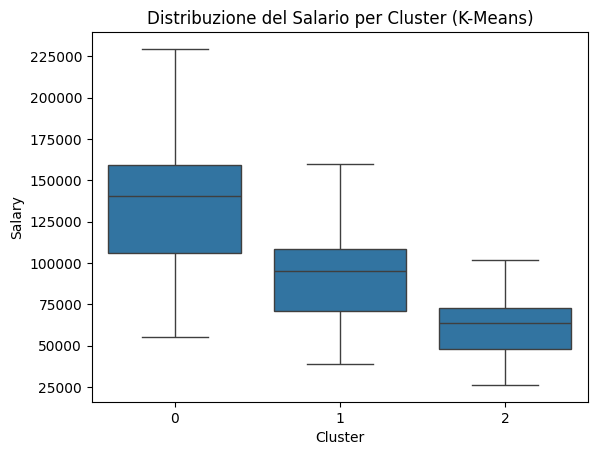

Media salario per cluster:
Cluster
2     61304.07
1     91536.24
0    134709.19
Name: Salary, dtype: float64


In [ ]:
sns.boxplot(x='Cluster', y='Salary', data=df)
plt.title('Distribuzione del Salario per Cluster (K-Means)')
plt.xlabel('Cluster')
plt.ylabel('Salary')
plt.show()

print("Media salario per cluster:")
print(df.groupby('Cluster')['Salary'].mean().sort_values().round(2))

### 14.2 Confronto K-Means e DBSCAN

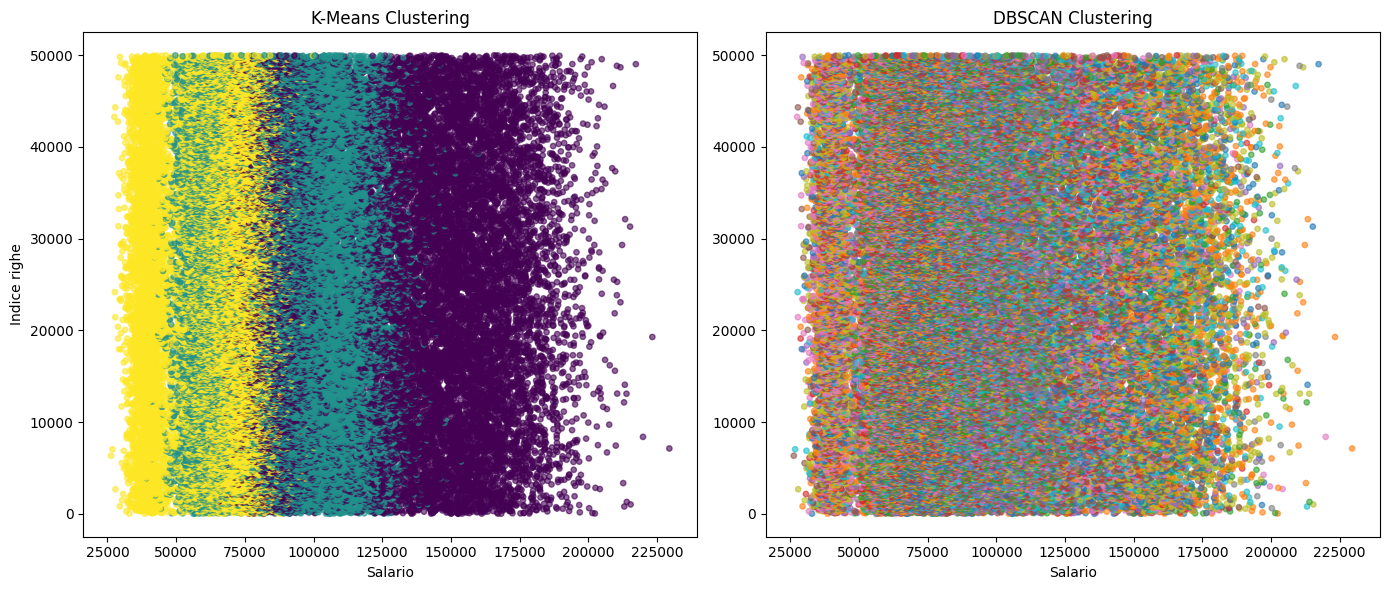

DBSCAN ha individuato 168 cluster.


In [104]:
plt.figure(figsize=(14, 6))

# Grafico K-Means (Sinistra)
plt.subplot(1, 2, 1)
plt.scatter(df['Salary'], np.arange(len(df)), c=df['Cluster'], cmap='viridis', s=15, alpha=0.6)
plt.title('K-Means Clustering')
plt.xlabel('Salario')
plt.ylabel('Indice righe')

# Grafico DBSCAN (Destra)
plt.subplot(1, 2, 2)
plt.scatter(df['Salary'], np.arange(len(df)), c=df['Cluster_DBSCAN'], cmap='tab10', s=15, alpha=0.6)
plt.title('DBSCAN Clustering')
plt.xlabel('Salario')

plt.tight_layout()
plt.show()

# Controlliamo quanti cluster ha trovato DBSCAN ora
n_clusters = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'] else 0)
print(f"DBSCAN ha individuato {n_clusters} cluster.")

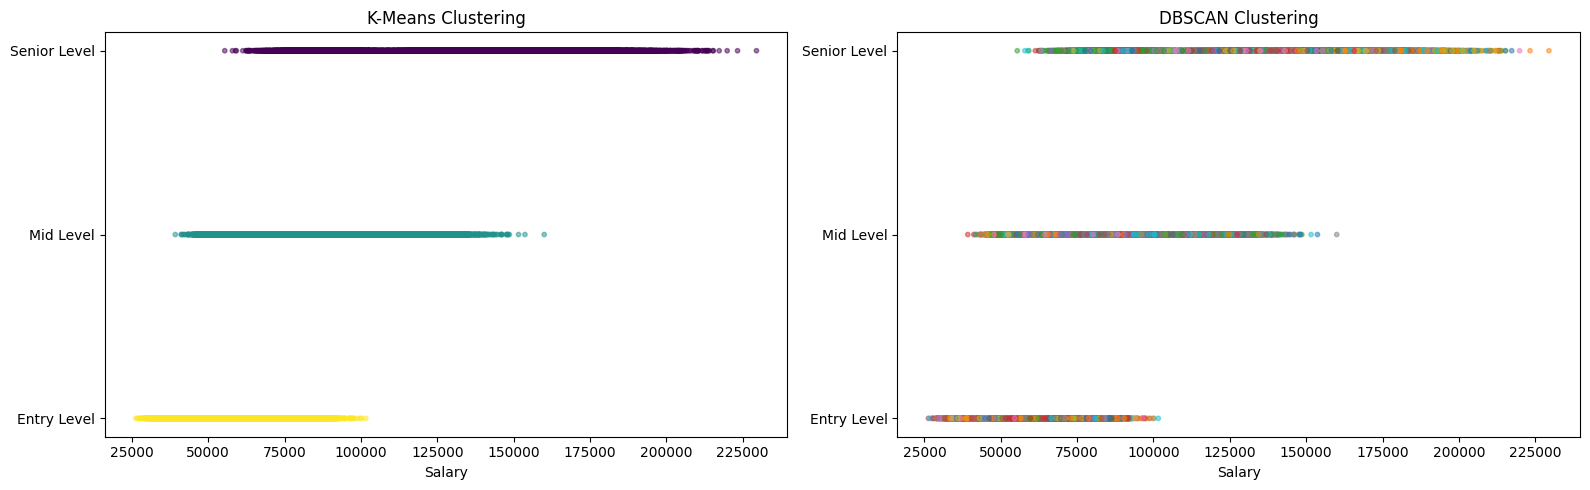

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# K-Means
axes[0].scatter(df['Salary'], df['exp_num'], c=df['Cluster'], cmap='viridis', s=10, alpha=0.5)
axes[0].set_yticks([0, 1, 2])
axes[0].set_yticklabels(['Entry Level', 'Mid Level', 'Senior Level'])
axes[0].set_xlabel('Salary')
axes[0].set_title('K-Means Clustering')

# DBSCAN
axes[1].scatter(df['Salary'], df['exp_num'], c=df['Cluster_DBSCAN'], cmap='tab10', s=10, alpha=0.5)
axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Entry Level', 'Mid Level', 'Senior Level'])
axes[1].set_xlabel('Salary')
axes[1].set_title('DBSCAN Clustering')

plt.tight_layout()
plt.show()

MACHINE LEARNING

In [105]:
y = df['Cluster']          # target = cluster trovato
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Logistic Regression
lr = LogisticRegression(max_iter=500)
lr.fit(X_train, y_train)
print(classification_report(y_test, lr.predict(X_test)))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(classification_report(y_test, rf.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3316
           1       1.00      1.00      1.00      3332
           2       1.00      1.00      1.00      3352

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3316
           1       1.00      1.00      1.00      3332
           2       1.00      1.00      1.00      3352

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

